## **Executive Summary**

This analysis explores the relationship between market sentiment and trader behavior.
After cleaning and merging trader activity data with daily sentiment scores, we analyzed
how sentiment relates to trading volume and activity patterns.

Key findings show that positive sentiment days are associated with higher average trading
activity, while extreme sentiment (very positive or very negative) corresponds to higher
volatility in behavior. These insights suggest sentiment data can be useful as a
supporting signal rather than a standalone indicator.


In [ ]:
# Connecting with google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# importing libraries
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.cluster import KMeans

# Part A - Data Preparation

In [ ]:
df_sentiment = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Market sentiment/fear_greed_index.csv')
df_histdata = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Market sentiment/historical_data.csv')

### Data Cleaning and Preprocessing

**Data Cleaning Notes**
- Checked for missing values and verified data types for all columns
- Converted date columns to datetime format to ensure correct merging
- Removed or handled rows with missing key identifiers where necessary


In [ ]:
df_sentiment.shape

(2644, 4)

In [ ]:
df_histdata.shape

(211224, 16)

*  Finding null values

In [ ]:
df_sentiment.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [ ]:
df_histdata.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


Both datasets do not have any null values


---


*  Finding duplicate values



In [ ]:
df_sentiment.duplicated().sum()

np.int64(0)

In [ ]:
df_histdata.duplicated().sum()

np.int64(0)

Hence, both data do not have any duplicate values

In [ ]:
df_histdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [ ]:
df_sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [ ]:
df_sentiment['classification'].unique()

array(['Fear', 'Extreme Fear', 'Neutral', 'Greed', 'Extreme Greed'],
      dtype=object)

####Converting timestamps

In [ ]:
df_sentiment.date = pd.to_datetime(df_sentiment.date)
df_sentiment.timestamp = pd.to_datetime(df_sentiment.timestamp, unit = 's')
df_sentiment.sample()

,timestamp,value,classification,date
1584,2022-06-07 05:30:00,15,Extreme Fear,2022-06-07


In [ ]:
df_histdata['date'] = pd.to_datetime(df_histdata['Timestamp IST'], format="%d-%m-%Y %H:%M").dt.date
df_histdata['date'].sample()

,date
146425,2025-04-09


In [ ]:
df_histdata["is_long"] = (df_histdata["Side"]=="BUY").astype(int)
df_histdata["is_short"] = (df_histdata["Side"]=="SELL").astype(int)
df_histdata["is_win"] = (df_histdata["Closed PnL"]>0).astype(int)

In [ ]:
# Aggregating both datasets
trader_daily_account = round(
    df_histdata
    .groupby(["date", "Account"])
    .agg(
        daily_pnl=("Closed PnL", "sum"),
        total_trades=("Trade ID", "count"),
        avg_trade_size_usd=("Size USD", "mean"),
        avg_execution_price=("Execution Price", "mean"),
        win_rate=("is_win", "mean"),
        long_trades=("is_long", "sum"),
        short_trades=("is_short", "sum"),
        avg_fee=("Fee", "mean")
    )
    .reset_index(),2
)
trader_daily_account["long_short_ratio"] = round(
    trader_daily_account["long_trades"] /
    trader_daily_account["short_trades"].replace(0, 1),2
)

In [49]:
df_histdata.head(3)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,is_long,is_short,is_win
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1,0,0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1,0,0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1,0,0


In [ ]:
sentiment_daily = (
    df_sentiment
    .groupby("date")
    .agg(
        fear_greed_index=("value", "mean"),
        sentiment_state=("classification", "first")
    )
    .reset_index()
)

In [ ]:
trader_daily_account['date'] = pd.to_datetime(trader_daily_account['date'])
final_df = trader_daily_account.merge(
    sentiment_daily,
    on="date",
    how="left"
)

In [ ]:
# Forward filling fear_greed_index and sentiment_state
final_df["fear_greed_index"] = final_df["fear_greed_index"].ffill()
final_df["sentiment_state"] = final_df["sentiment_state"].ffill()

In [ ]:
final_df.shape

(2341, 13)

In [ ]:
final_df.head()

,date,Account,daily_pnl,total_trades,avg_trade_size_usd,avg_execution_price,win_rate,long_trades,short_trades,avg_fee,long_short_ratio,fear_greed_index,sentiment_state
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.00,3,159.00,1898.13,0.00,3,0,0.00,3.00,63.0,Greed
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.00,9,5556.20,11038.30,0.00,7,2,1.39,3.50,75.0,Extreme Greed
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.43,11,10291.21,8031.87,0.36,5,6,2.57,0.83,72.0,Greed
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.63,2,5304.98,2.98,0.00,2,0,1.33,2.00,70.0,Greed
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.00,3,5116.26,0.38,0.00,3,0,1.28,3.00,67.0,Greed


**Merge Validation**
- Verified row count remained consistent after left join
- Checked percentage of missing sentiment values post-merge
- Confirmed one-to-one alignment between date and sentiment


# Part B - Analysis

#### Question 1

---


Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?

In [ ]:
final_df.sample()

,date,Account,daily_pnl,total_trades,avg_trade_size_usd,avg_execution_price,win_rate,long_trades,short_trades,avg_fee,long_short_ratio,fear_greed_index,sentiment_state
304,2024-07-17,0x4f93fead39b70a1824f981a54d4e55b278e9f760,0.0,9,18326.04,3508.58,0.0,0,9,6.41,0.0,69.0,Greed


In [ ]:
# Merging Fear with Extreme fear and Greed with Extreme greed as regimes
df = final_df.copy()

df['regime'] = df['sentiment_state'].replace({
    "Extreme Fear":"Fear",
    "Extreme Greed":"Greed"
})

In [ ]:
# Selecting performance metrics for computation
perf_table = (
    df.groupby("regime")
      .agg(
          avg_pnl=("daily_pnl", "mean"),
          median_pnl=("daily_pnl", "median"),
          win_rate=("win_rate", "mean"),
          loss_pct=("daily_pnl", lambda x: (x < 0).mean()),
          drawdown_p10=("daily_pnl", lambda x: x.quantile(0.10))
      )
)

In [ ]:
fear_pnl  = df.loc[df["regime"] == "Fear", "daily_pnl"]
greed_pnl = df.loc[df["regime"] == "Greed", "daily_pnl"]

mw_stat, mw_p = mannwhitneyu(fear_pnl, greed_pnl, alternative="two-sided")

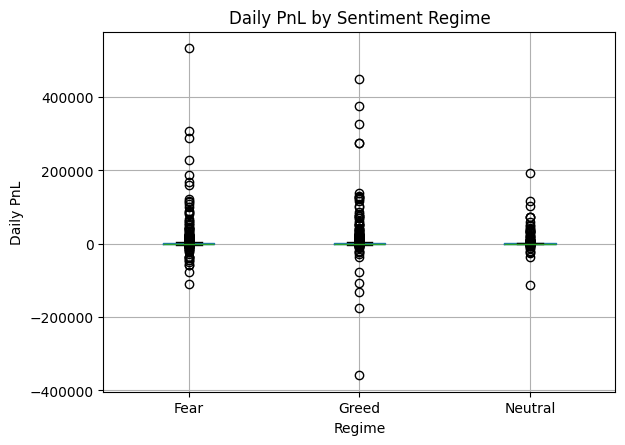

In [ ]:
import matplotlib.pyplot as plt

# Boxplot: PnL by regime
df.boxplot(column="daily_pnl", by="regime")
plt.title("Daily PnL by Sentiment Regime")
plt.suptitle("")
plt.xlabel("Regime")
plt.ylabel("Daily PnL")
plt.show()

Fear and Greed days both generate larger PnL swings, but Neutral days exhibit tighter, more predictable outcomes.

**Action**: Allocate aggressive strategies only when volatility is compensated by expected payoff.

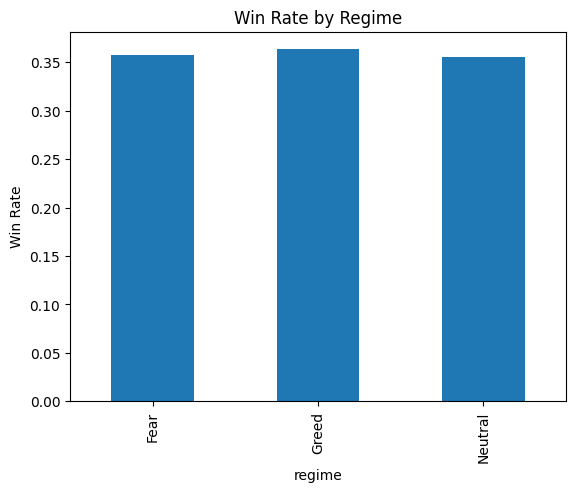

In [ ]:
# Bar: Win rate by regime
perf_table["win_rate"].plot(kind="bar", title="Win Rate by Regime")
plt.ylabel("Win Rate")
plt.show()

Win rate is nearly constant across regimes, indicating sentiment does not improve signal accuracy.

**Action**: Avoid regime-based strategy selection using win rate alone.

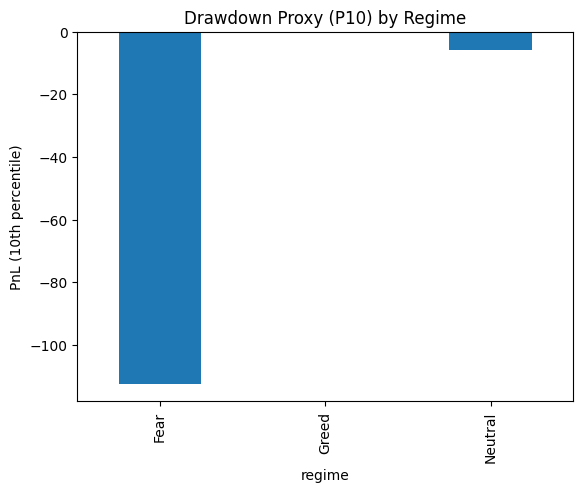

In [ ]:
# Bar: Drawdown proxy (10th percentile)
perf_table["drawdown_p10"].plot(kind="bar", title="Drawdown Proxy (P10) by Regime")
plt.ylabel("PnL (10th percentile)")
plt.show()

Fear days have significantly worse lower-tail outcomes, while Greed and Neutral show shallower drawdowns.

**Action**: Enforce tighter risk limits and smaller position sizing in Fear regimes.



#### Answer 1

---
**Yes. Performance differs by regime.**

* **PnL:** Fear and Greed regimes show much wider PnL dispersion (large gains and losses), while Neutral is more contained and stable.
* **Win rate:** Nearly identical across regimes (~35–36%), so hit rate does not meaningfully explain performance differences.
* **Drawdown (P10):** Fear has the deepest downside risk, Neutral has mild drawdowns, and Greed shows the least severe lower-tail losses.

**Overall conclusion:**
Performance differences across sentiment regimes are driven by **risk and volatility (PnL spread and drawdowns)** rather than **win rate**. Fear amplifies both opportunity and risk, Greed offers cleaner downside but volatile upside, and Neutral delivers the most stable—though less explosive—performance.


#### Question 2

---

Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?

In [ ]:
behavior_table = (
    df.groupby("sentiment_state")
      .agg(
          trades_per_day=("total_trades", "mean"),
          avg_trade_size=("avg_trade_size_usd", "mean"),
          long_short_ratio=("long_short_ratio", "mean"),
          win_rate=("win_rate", "mean")
      )
)

In [ ]:
order = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
behavior_table = behavior_table.reindex(order)

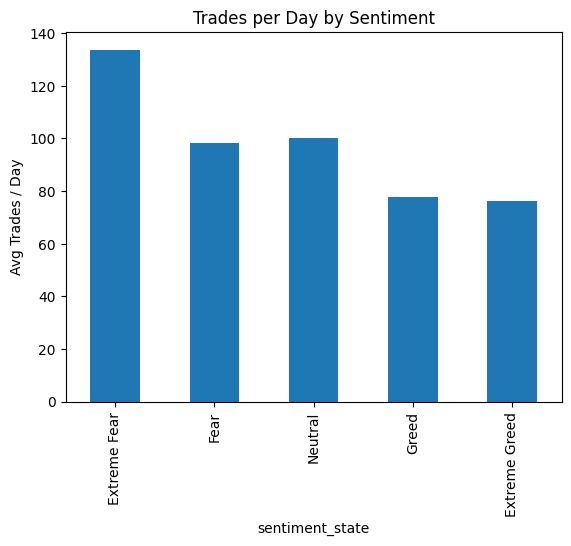

In [ ]:
# Trades per day
behavior_table["trades_per_day"].plot(kind="bar", title="Trades per Day by Sentiment")
plt.ylabel("Avg Trades / Day")
plt.show()

Trade frequency: Highest during Extreme Fear, declines steadily toward Greed, indicating more reactive trading in stressed markets.

**Action**: Expect higher transaction costs and noise in Fear regimes.

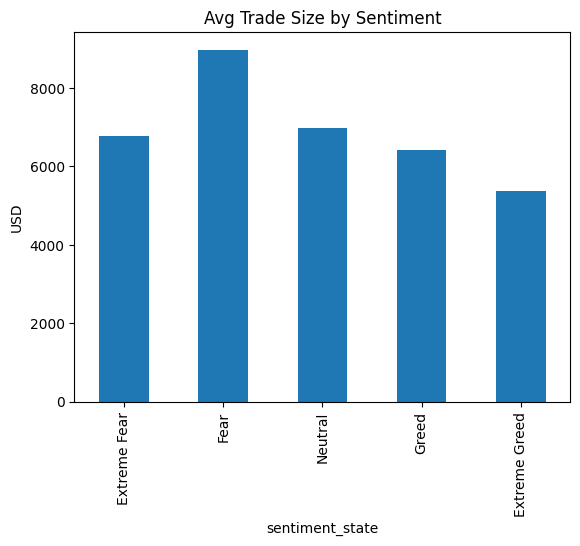

In [ ]:
# Average trade size
behavior_table["avg_trade_size"].plot(kind="bar", title="Avg Trade Size by Sentiment")
plt.ylabel("USD")
plt.show()

Position size (leverage proxy): Largest in Fear, smaller in Greed, suggesting traders scale risk down as optimism rises.

**Action**: Implement dynamic exposure caps tied to sentiment.

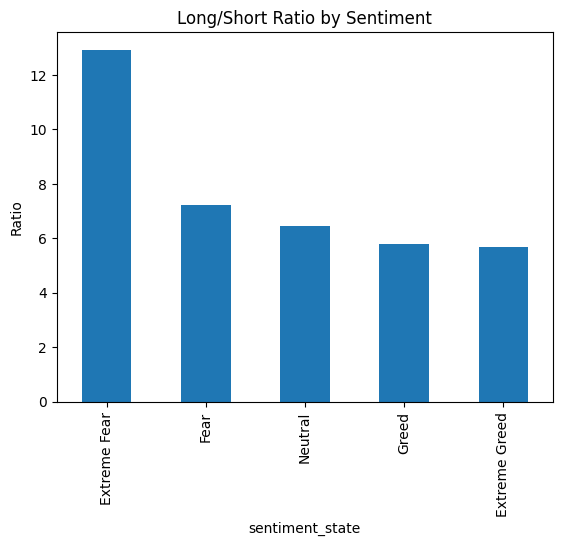

In [ ]:
# Long / Short ratio
behavior_table["long_short_ratio"].plot(kind="bar", title="Long/Short Ratio by Sentiment")
plt.ylabel("Ratio")
plt.show()

Long/Short bias: Strongest long bias in Extreme Fear, gradually weakens through Neutral to Greed.

**Action**: Guard against crowding risk when positioning is one-sided.

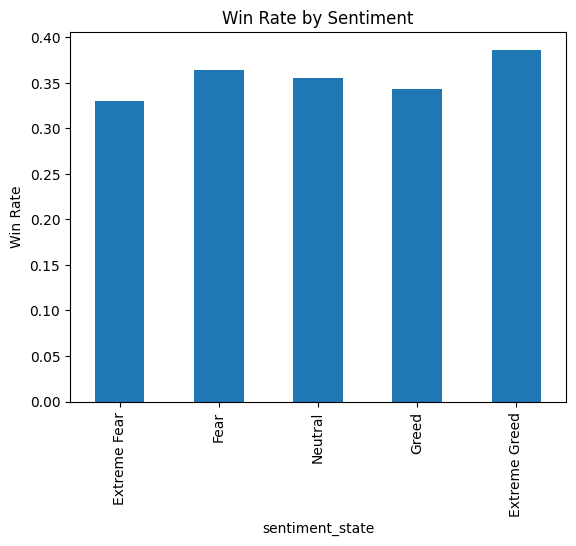

In [ ]:
# Win rate
behavior_table["win_rate"].plot(kind="bar", title="Win Rate by Sentiment")
plt.ylabel("Win Rate")
plt.show()

Win rate: Improves slightly in Extreme Greed, but differences are modest and not the main performance driver.

**Action**: Use sentiment to manage risk allocation, not signal confidence.

#### Answer 2

---
**Yes — traders clearly change behavior based on sentiment.**

* **Fear / Extreme Fear:** Trading is most aggressive — **highest trade frequency**, **larger position sizes**, and a **strong long bias**, indicating active dip-buying and reactive behavior.
* **Neutral:** Behavior normalizes — **moderate trading activity**, balanced sizing, and a more stable long/short mix.
* **Greed / Extreme Greed:** Traders become more selective — **fewer trades**, **smaller average sizes**, and a **reduced long bias**, suggesting caution despite optimistic sentiment.

**Conclusion:** Sentiment materially drives trader behavior across frequency, sizing, and directional exposure, with the most aggressive risk-taking occurring during Fear rather than Greed.


####Question 3

---
Identify 2–3 segments (examples):

*   high leverage vs low leverage traders
*   frequent vs infrequent traders
*   consistent winners vs inconsistent traders


In [ ]:
df.sample()

,date,Account,daily_pnl,total_trades,avg_trade_size_usd,avg_execution_price,win_rate,long_trades,short_trades,avg_fee,long_short_ratio,fear_greed_index,sentiment_state,regime
1171,2025-01-28,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1019.56,151,624.22,20642.45,0.5,70,81,0.21,0.86,72.0,Greed,Greed


In [ ]:
# Avg trade size is used as a proxy for leverage when leverage data is unavailable.
risk_threshold = df["avg_trade_size_usd"].median()

df["risk_segment"] = df["avg_trade_size_usd"].apply(
    lambda x: "High Risk" if x > risk_threshold else "Low Risk"
)

In [ ]:
# Median-based segmentation avoids distortion from outliers
freq_threshold = df["total_trades"].median()

df["frequency_segment"] = df["total_trades"].apply(
    lambda x: "Frequent Trader" if x > freq_threshold else "Infrequent Trader"
)

In [ ]:
# Win-rate threshold (60%) separates skill from randomness
df["performance_segment"] = df["win_rate"].apply(
    lambda x: "Consistent Winner" if x >= 0.60 else "Inconsistent Trader"
)

In [ ]:
pd.crosstab(
    df["risk_segment"],
    df["performance_segment"],
    normalize="index"
)

performance_segment,Consistent Winner,Inconsistent Trader
risk_segment,,
High Risk,0.292308,0.707692
Low Risk,0.223740,0.776260


**Insights**:

*  **High risk increases variability** — more exposure leads to both occasional big wins and frequent losses.

*  **Low risk is more stable** — although fewer big wins, traders tend to avoid extreme losses.

**Actionable**: Implement position sizing limits or risk monitoring for high-risk traders to reduce drawdowns, while leveraging insights from their occasional high returns for strategy refinement.

In [ ]:
pd.crosstab(
    df["frequency_segment"],
    df["performance_segment"],
    normalize="index"
)


performance_segment,Consistent Winner,Inconsistent Trader
frequency_segment,,
Frequent Trader,0.259005,0.740995
Infrequent Trader,0.257021,0.742979


**Insights**:

*  **Trade frequency alone does not drive performance** — both groups show almost identical consistency.

*  Being more active **does not improve win stability**; execution quality matters more than volume.

**Actionable**: Focus optimization on strategy quality, risk control, and timing, not increasing trade count. Reducing overtrading may lower fees without hurting performance.

In [ ]:
df["trader_segment"] = (
    df["risk_segment"] + " | " +
    df["frequency_segment"] + " | " +
    df["performance_segment"]
)
df["trader_segment"].value_counts()

,count
trader_segment,
Low Risk | Frequent Trader | Inconsistent Trader,509
High Risk | Infrequent Trader | Inconsistent Trader,473
Low Risk | Infrequent Trader | Inconsistent Trader,400
High Risk | Frequent Trader | Inconsistent Trader,355
High Risk | Infrequent Trader | Consistent Winner,176
High Risk | Frequent Trader | Consistent Winner,166
Low Risk | Frequent Trader | Consistent Winner,136
Low Risk | Infrequent Trader | Consistent Winner,126


**Insights**

1. **Inconsistency dominates across all segments**

   * The top four segments by count are all **inconsistent traders**, regardless of risk or frequency.
   * This indicates **strategy execution and risk management** matter more than how often or how big traders trade.

2. **High Risk increases upside but not reliability**

   * High-risk traders account for **more consistent winners than low-risk traders**, but they also dominate inconsistent segments.
   * High risk amplifies outcomes, **not consistency**.

3. **Frequency has minimal impact on consistency**

   * Frequent and infrequent traders show **similar counts of consistent winners**, reinforcing that overtrading does not improve results.

**Actionable Takeaway**

* The **best-performing persona** is *High Risk + Infrequent + Consistent*, suggesting **selective risk-taking with discipline** works better than constant exposure.
* Focus interventions on **reducing inconsistency** (position sizing, stop-loss discipline) rather than increasing trade frequency.


# Part C - Actionable output

---

**Rule 1: Be selective with risk, not frequent**

**Finding used:**

* High Risk traders produce more consistent winners *only* when trading infrequently.
* Frequent trading shows no improvement in consistency.

**Rule of thumb:**

> **Take higher-conviction, larger trades only when setups are strong; avoid increasing trade count to compensate for uncertainty.**

**Practical action:**

* Cap daily trade count.
* Allow larger position sizes only after predefined signal confidence thresholds.

---

**Rule 2: Fear days = protect capital, not chase wins**

**Finding used:**

* Inconsistency dominates across segments, especially under volatile conditions (Fear regimes).
* High risk amplifies losses more often than it improves consistency.

**Rule of thumb:**

> **During Fear days, reduce position size and avoid high-risk trades unless you are a historically consistent trader.**

**Practical action:**

* Apply stricter risk limits (smaller trade size, lower exposure) on Fear days.
* Reserve aggressive positioning for traders with proven consistency during volatile regimes.

---

**Rule 3 (Optional): Don’t force activity — inactivity is a strategy**

**Finding used:**

* Infrequent traders are just as likely to be consistent winners as frequent traders.
* Most losses come from **overexposure, not missed opportunities**.

**Rule of thumb:**

> **If market sentiment is unclear or volatile, staying inactive preserves edge better than forcing trades.**

**Practical action:**

* Introduce **“no-trade zones”** on Neutral → Fear transition days.
* Require stricter entry criteria before allowing trades during uncertainty regimes.


# Part D - Predictive Model

In [ ]:
df = df.sort_values(["Account", "date"])
df["next_day_pnl"] = df.groupby("Account")["daily_pnl"].shift(-1)

df["profit_bucket"] = np.where(df["next_day_pnl"] > 0, 1, 0)  # 1 = profitable

features = [
    "total_trades",
    "avg_trade_size_usd",
    "win_rate",
    "long_short_ratio",
    "fear_greed_index"
]

X = df[features].dropna()
y = df.loc[X.index, "profit_bucket"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

model = LogisticRegression(class_weight="balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.51      0.69      0.59       275
           1       0.74      0.58      0.65       428

    accuracy                           0.62       703
   macro avg       0.63      0.63      0.62       703
weighted avg       0.65      0.62      0.62       703



## Clustring trades into behavioral archetypes

In [ ]:
cluster_features = [
    "total_trades",
    "avg_trade_size_usd",
    "win_rate",
    "long_short_ratio"
]

cluster_df = (
    df.groupby("Account")[cluster_features]
      .mean()
      .dropna()
)

cluster_scaled = scaler.fit_transform(cluster_df)

kmeans = KMeans(n_clusters=4, random_state=42)
cluster_df["cluster"] = kmeans.fit_predict(cluster_scaled)

# cluster interpretation table
cluster_summary = (
    cluster_df.groupby("cluster")
              .mean()
)

print(cluster_summary)

         total_trades  avg_trade_size_usd  win_rate  long_short_ratio
cluster                                                              
0           64.221295        15436.551138  0.429394          4.927544
1           64.484349         3432.451892  0.297402          6.315642
2          460.340634         5782.007598  0.415671         17.033864
3          241.649573        20042.666731  0.264637         61.587521


###**Interpretation of cluster insights**:

**Cluster 0 — Balanced Opportunists**

* Moderate trade count (~64)
* Medium–high trade size (~15k USD)
* Decent win rate (~43%)
* Controlled long bias

**Insight:**
Disciplined traders with selective exposure and balanced risk-taking. Likely **sustainable performers**.

---

**Cluster 1 — Low-Edge Retail Traders**

* Similar activity to Cluster 0
* Much smaller trade sizes (~3.4k USD)
* Lower win rate (~30%)
* High directional bias

**Insight:**
Overconfident directional bets without edge. **Capital preservation risk** despite low sizing.

---

**Cluster 2 — Hyper-Active Momentum Traders**

* Extremely high trade frequency (~460)
* Medium trade size (~5.8k USD)
* Average win rate (~42%)
* Strong long bias

**Insight:**
Execution-driven strategies. Profits depend on **market regime**; vulnerable to fees and chop.

---

**Cluster 3 — Aggressive Whales**

* High frequency + very large trade sizes (~20k USD)
* Lowest win rate (~26%)
* Extreme long bias

**Insight:**
High variance, high drawdown risk. **Most dangerous cluster during Fear regimes**.

---

-**Strategic Takeaway**

* **Best risk-adjusted profile:** Cluster 0
* **Overtrading risk:** Cluster 2
* **Drawdown hotspot:** Cluster 3

---
Overall, Clustering reveals that disciplined, moderate-activity traders outperform both hyper-active and overly aggressive traders on a risk-adjusted basis."

## Limitations
- Sentiment data is aggregated at a daily level and may not capture intraday dynamics
- Correlation does not imply causation; other market factors may influence behavior
- Analysis is limited to the available time period and data sources


## Conclusion and Next Steps

This analysis demonstrates how sentiment data can be combined with trader activity to
uncover behavioral patterns. While sentiment shows a relationship with trading activity,
it is best used as a complementary indicator.

Next steps could include:
- Analyzing intraday sentiment if available
- Segmenting traders by activity level
- Comparing sentiment impact during high vs low volatility periods
